# Assignment 10

In [1]:
import os
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
from tensorflow.keras.utils import to_categorical

# *Part 1: Data Preparation*

In [2]:
def load_image_dataset(folder_path):
    images = []
    labels = []
    for file in os.listdir(folder_path):
        image_path = os.path.join(folder_path, file)
        image = load_img(image_path, target_size=(64,64))
        image_array = img_to_array(image)
        image_array_normalized = image_array/255.0
        images.append(image_array_normalized)
        if 'NORMAL' in folder_path:
            labels.append(0)
        else:
            labels.append(1)       
    return np.array(images), np.array(labels)

def display_first_three_images(images):
    plt.figure(figsize=(15, 5))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

NORMAL IMAGES


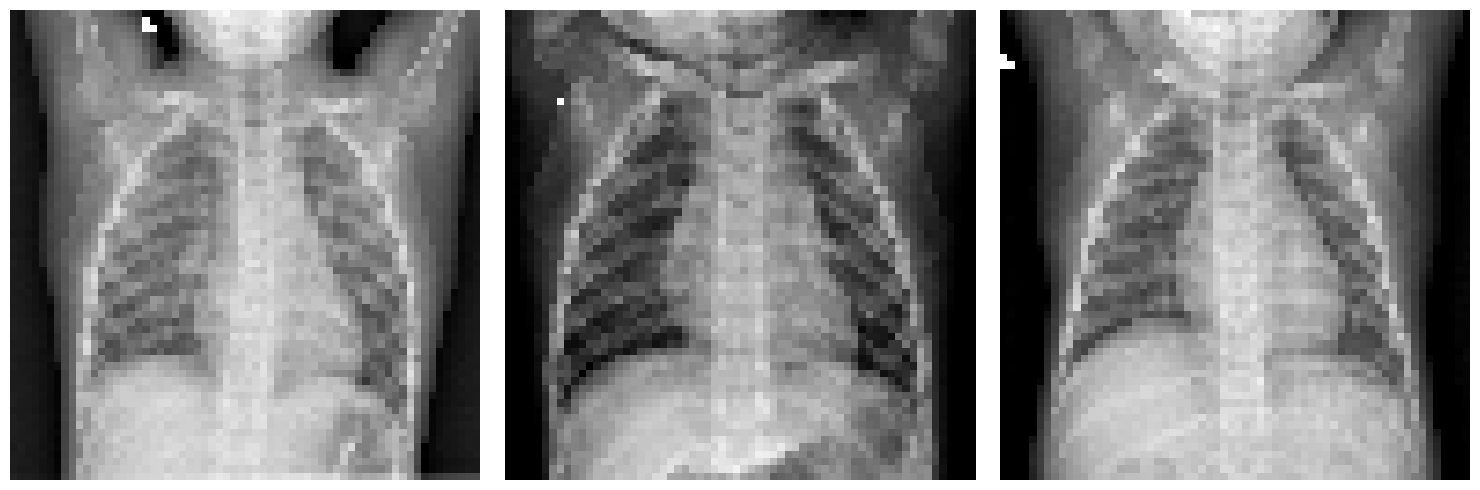

PNEUMONIA IMAGES


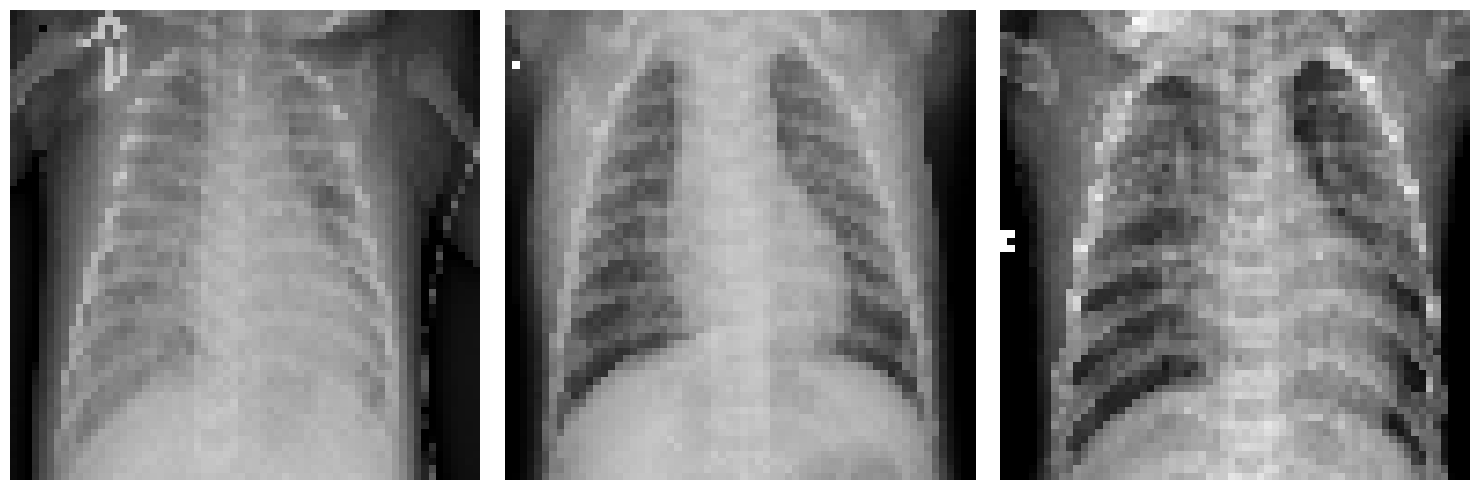

In [3]:
normal_path = 'train/NORMAL'
pneumonia_path = 'train/PNEUMONIA'

X_normal, y_normal = load_image_dataset(normal_path)
X_pneumonia, y_pneumonia = load_image_dataset(pneumonia_path)

print('NORMAL IMAGES')
display_first_three_images(X_normal)
print('PNEUMONIA IMAGES')
display_first_three_images(X_pneumonia)

In [4]:
X_normal_train, X_normal_test, y_normal_train, y_normal_test = train_test_split(X_normal, y_normal, test_size=0.2, random_state=24)
X_pneumonia_train, X_pneumonia_test, y_pneumonia_train, y_pneumonia_test = train_test_split(X_pneumonia, y_pneumonia, test_size=0.2, random_state=24)

print('Normal Training Set Shape:', X_normal_train.shape)
print('Normal Test Set Shape:', X_normal_test.shape)
print('Pneumonia Training Set Shape:', X_pneumonia_train.shape)
print('Pneumonia Test Set Shape:', X_pneumonia_test.shape)

Normal Training Set Shape: (1072, 64, 64, 3)
Normal Test Set Shape: (269, 64, 64, 3)
Pneumonia Training Set Shape: (3100, 64, 64, 3)
Pneumonia Test Set Shape: (775, 64, 64, 3)


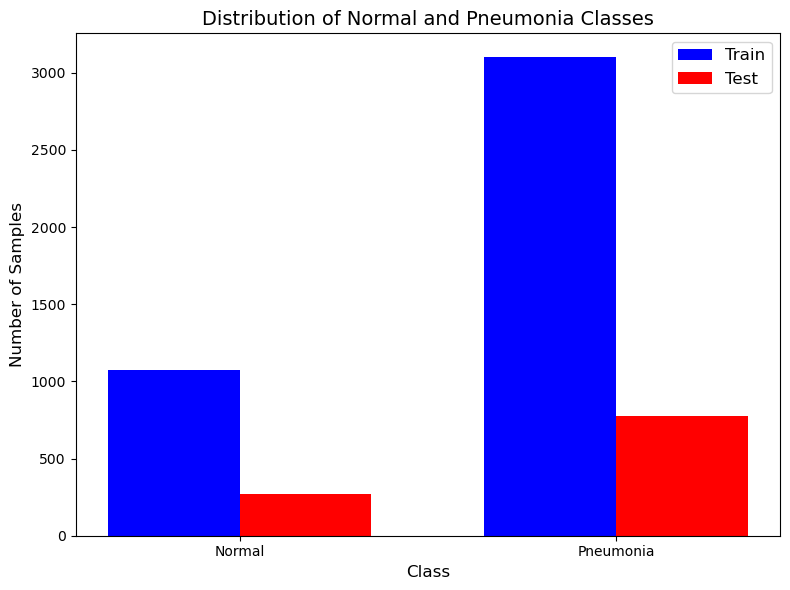

In [5]:
classes = ['Normal', 'Pneumonia']
train_counts = [X_normal_train.shape[0], X_pneumonia_train.shape[0]]
test_counts = [X_normal_test.shape[0], X_pneumonia_test.shape[0]]
x = np.arange(len(classes))  
width = 0.35  

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, train_counts, width, label='Train', color='blue')
ax.bar(x + width/2, test_counts, width, label='Test', color='red')

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Distribution of Normal and Pneumonia Classes', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=10)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Class')

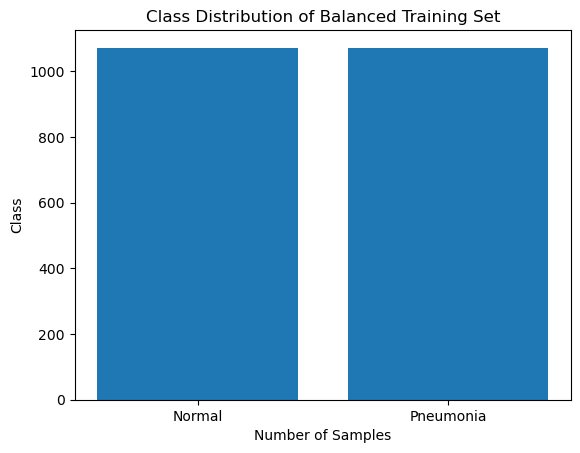

In [6]:
np.random.seed(24)
rand_index = np.random.choice(X_pneumonia_train.shape[0], X_normal_train.shape[0], replace=False)
X_pneumonia_train_balanced = X_pneumonia_train[rand_index]
y_pneumonia_train_balanced = y_pneumonia_train[rand_index]

plt.bar(classes, [X_normal_train.shape[0], X_pneumonia_train_balanced.shape[0]])
plt.title('Class Distribution of Balanced Training Set')
plt.xlabel('Number of Samples')
plt.ylabel('Class')

# *Part 2: Model Building* 

In [7]:
model_cnn = Sequential()

model_cnn.add(Input(shape=(64, 64, 3)))
model_cnn.add(Conv2D(filters=10, kernel_size=(3,3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))
model_cnn.add(Conv2D(filters=20, kernel_size=(3,3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

model_cnn.add(Flatten())
model_cnn.add(Dense(128))
model_cnn.add(Dropout(rate=0.5))
model_cnn.add(Dense(2))
model_cnn.add(Activation('softmax'))

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 10)     │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 20)     │         1,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       501,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504,246 (1.92 MB)

 Trainable params: 504,246 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
X_train_balanced = np.concatenate((X_normal_train, X_pneumonia_train_balanced), axis=0)
y_train_balanced = np.concatenate((y_normal_train, y_pneumonia_train_balanced), axis=0)
X_test = np.concatenate((X_normal_test, X_pneumonia_test), axis=0)
y_test = np.concatenate((y_normal_test, y_pneumonia_test), axis=0)

y_train_balanced_one_hot = to_categorical(y_train_balanced, num_classes=2)
y_test_one_hot = to_categorical(y_test, num_classes=2)

history = model_cnn.fit(X_train_balanced, y_train_balanced_one_hot, validation_data=(X_test, y_test_one_hot), batch_size=64, epochs=20, verbose=1)
print('Baseline Validation Accuracy:', history.history['val_accuracy'][-1])
print('Baseline Validation Loss:', history.history['val_loss'][-1])

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6324 - loss: 0.7947 - val_accuracy: 0.8228 - val_loss: 0.3983
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9222 - loss: 0.2009 - val_accuracy: 0.9425 - val_loss: 0.1419
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9183 - loss: 0.2106 - val_accuracy: 0.9588 - val_loss: 0.1091
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9642 - loss: 0.1075 - val_accuracy: 0.9569 - val_loss: 0.1080
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9629 - loss: 0.0988 - val_accuracy: 0.9588 - val_loss: 0.0988
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9649 - loss: 0.0889 - val_accuracy: 0.9569 - val_loss: 0.0991
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9675 - loss: 0.0770 - val_accuracy: 0.9540 - val_loss: 0.1316
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9693 - loss: 0.0759 - val_accuracy: 0.9607 - v

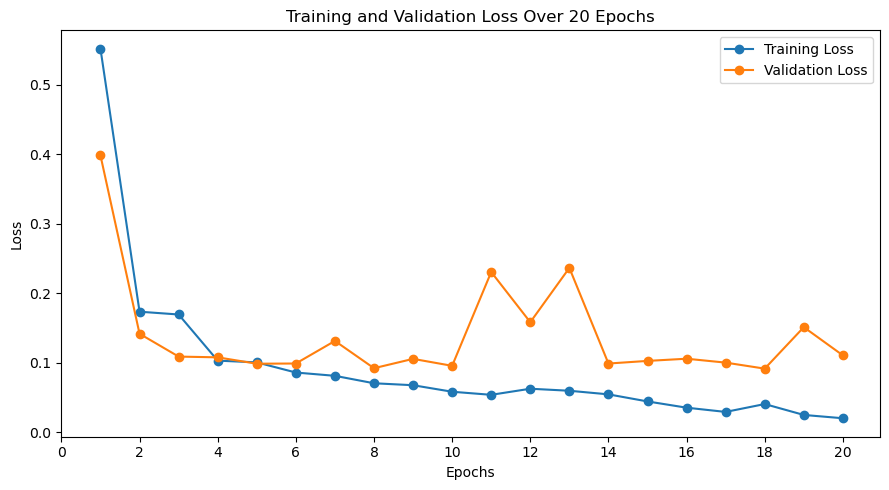

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(range(1,21), history.history['loss'], label='Training Loss', marker='o')
plt.plot(range(1,21), history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss Over 20 Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.xticks(range(0,21,2))
plt.tight_layout()
plt.show()

From the plot above, we can see that after the first epoch, there is a significant decrease in the training and validation loss meaning that the model learns a lot about the patterns in the training data quite quickly. Furthermore, we can see that after reaching the tenth epoch, the validation performance starts to behave erratically as the training loss continues to steadily decrease. This could be due to the gradient descent algorithm missing a local minimum in the loss function and temporarily moving in the wrong direction before eventually finding moving back toward the local minimum which we can see above. One way that we can avoid this behavior in the validation loss is to use a smaller batch size which will allow the gradient descent algorithm to make more incremental updates and hopefully find the local minimum of the loss in a much smoother manner. However, in terms of overall performance, we have already achieved a validation accuracy of about 96% which is quite solid for a baseline model without hyperparameter tuning.  

# *Part 3: Hyperparameter Tuning and Model Evaluation*

In [10]:
def evaluate_cnn(batch_size, filter_size, num_filter):
    model_cnn = Sequential()
    
    model_cnn.add(Input(shape=(64, 64, 3)))
    model_cnn.add(Conv2D(filters=num_filter[0], kernel_size=filter_size, activation='relu'))
    model_cnn.add(MaxPooling2D(pool_size=(2,2)))
    model_cnn.add(Conv2D(filters=num_filter[1], kernel_size=filter_size, activation='relu'))
    model_cnn.add(MaxPooling2D(pool_size=(2,2)))
    
    model_cnn.add(Flatten())
    model_cnn.add(Dense(128))
    model_cnn.add(Dropout(rate=0.5))
    model_cnn.add(Dense(2))
    model_cnn.add(Activation('softmax'))
    
    model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model_cnn.fit(X_train_balanced, y_train_balanced_one_hot, validation_data=(X_test, y_test_one_hot), batch_size=batch_size, epochs=20, verbose=0)
    
    return history

Validation Accuracy (Batch Size: 16 | Filter Size: (3, 3) | Number of Filters: (32, 64)): 0.9664750695228577
Validation Loss (Batch Size: 16 | Filter Size: (3, 3) | Number of Filters: (32, 64)): 0.19573737680912018


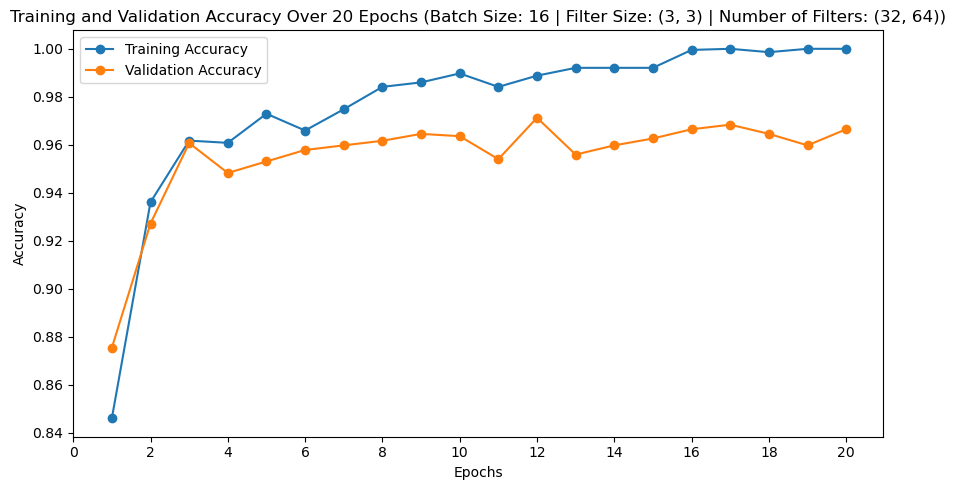

Validation Accuracy (Batch Size: 16 | Filter Size: (3, 3) | Number of Filters: (64, 128)): 0.9655172228813171
Validation Loss (Batch Size: 16 | Filter Size: (3, 3) | Number of Filters: (64, 128)): 0.24413108825683594


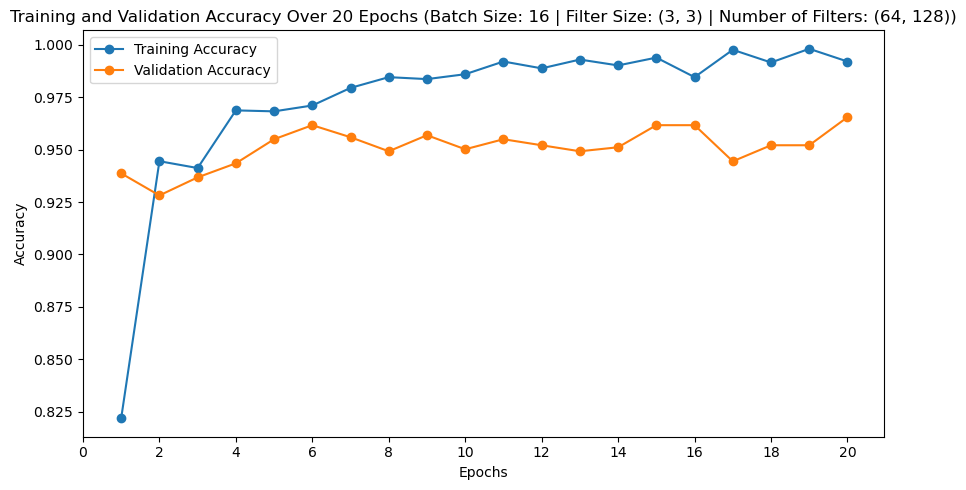

Validation Accuracy (Batch Size: 16 | Filter Size: (5, 5) | Number of Filters: (32, 64)): 0.959770143032074
Validation Loss (Batch Size: 16 | Filter Size: (5, 5) | Number of Filters: (32, 64)): 0.1367596834897995


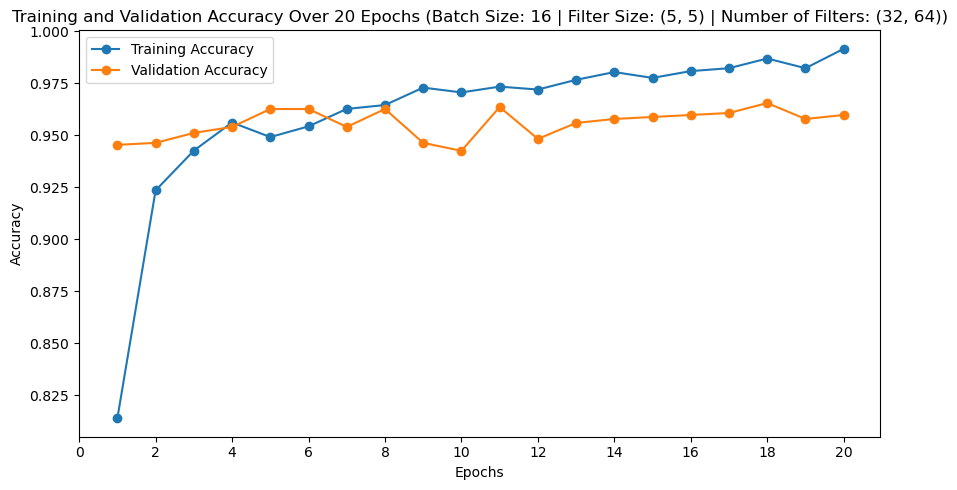

Validation Accuracy (Batch Size: 16 | Filter Size: (5, 5) | Number of Filters: (64, 128)): 0.9329501986503601
Validation Loss (Batch Size: 16 | Filter Size: (5, 5) | Number of Filters: (64, 128)): 0.2418402135372162


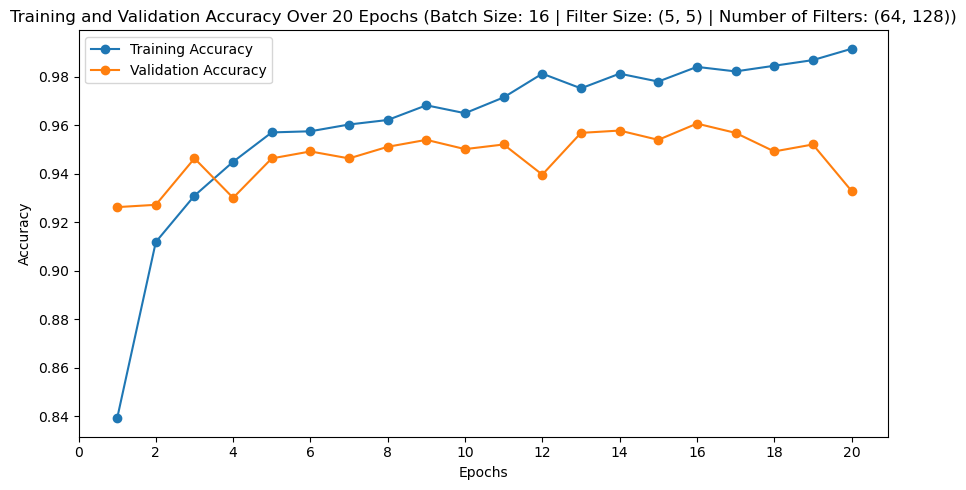

Validation Accuracy (Batch Size: 16 | Filter Size: (7, 7) | Number of Filters: (32, 64)): 0.961685836315155
Validation Loss (Batch Size: 16 | Filter Size: (7, 7) | Number of Filters: (32, 64)): 0.13712532818317413


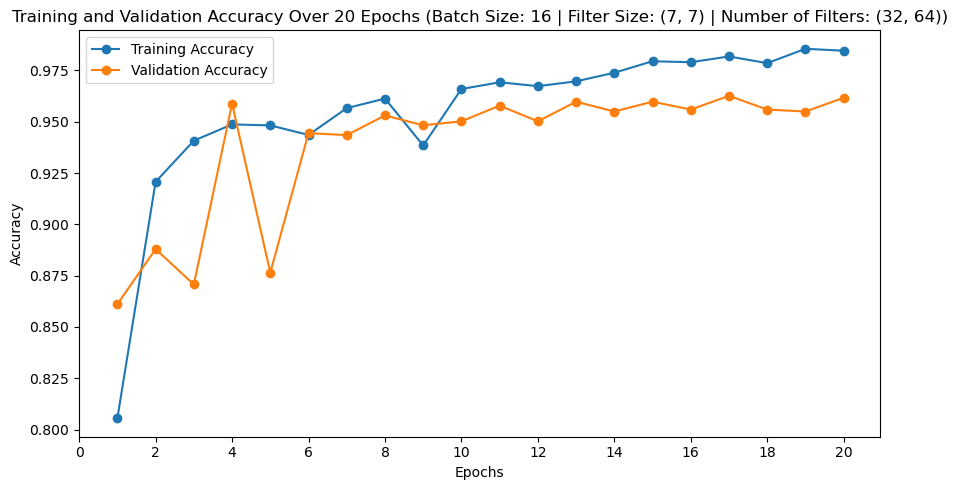

Validation Accuracy (Batch Size: 16 | Filter Size: (7, 7) | Number of Filters: (64, 128)): 0.9578543901443481
Validation Loss (Batch Size: 16 | Filter Size: (7, 7) | Number of Filters: (64, 128)): 0.16683197021484375


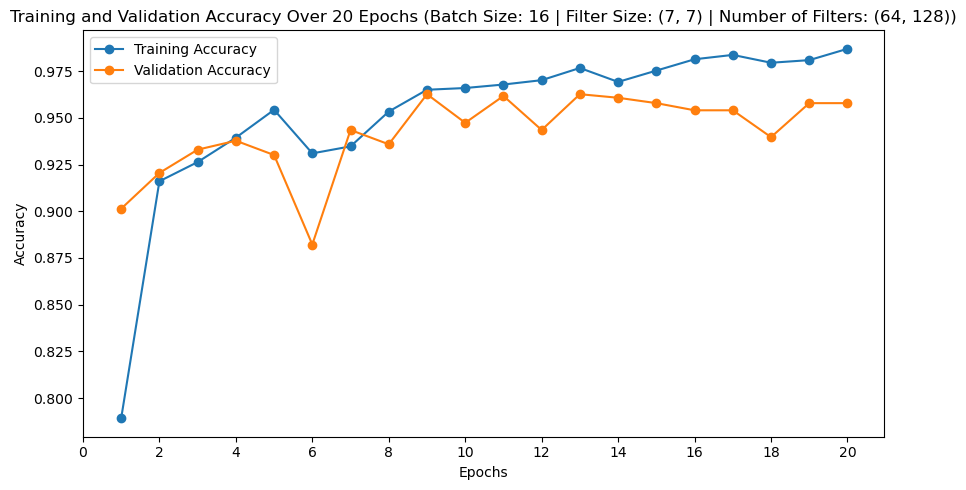

Validation Accuracy (Batch Size: 32 | Filter Size: (3, 3) | Number of Filters: (32, 64)): 0.9683908224105835
Validation Loss (Batch Size: 32 | Filter Size: (3, 3) | Number of Filters: (32, 64)): 0.14572572708129883


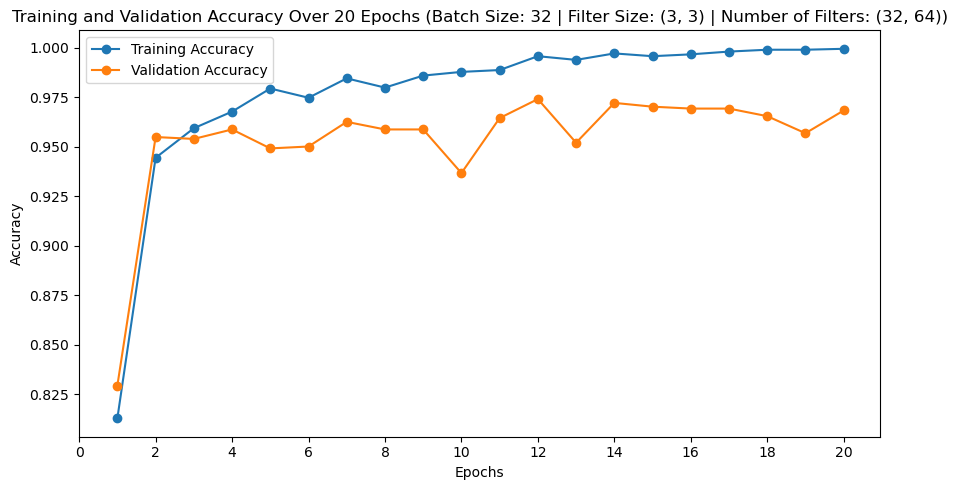

Validation Accuracy (Batch Size: 32 | Filter Size: (3, 3) | Number of Filters: (64, 128)): 0.967432975769043
Validation Loss (Batch Size: 32 | Filter Size: (3, 3) | Number of Filters: (64, 128)): 0.1686042994260788


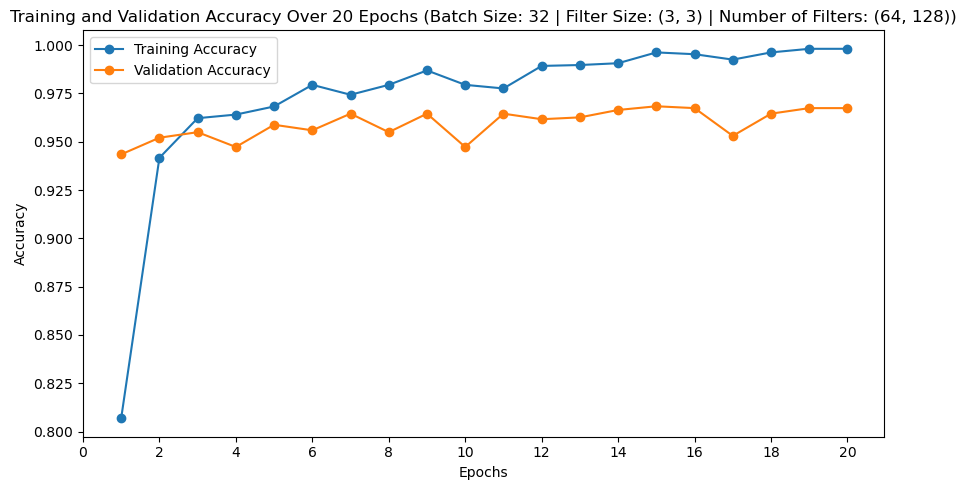

Validation Accuracy (Batch Size: 32 | Filter Size: (5, 5) | Number of Filters: (32, 64)): 0.9683908224105835
Validation Loss (Batch Size: 32 | Filter Size: (5, 5) | Number of Filters: (32, 64)): 0.1273525506258011


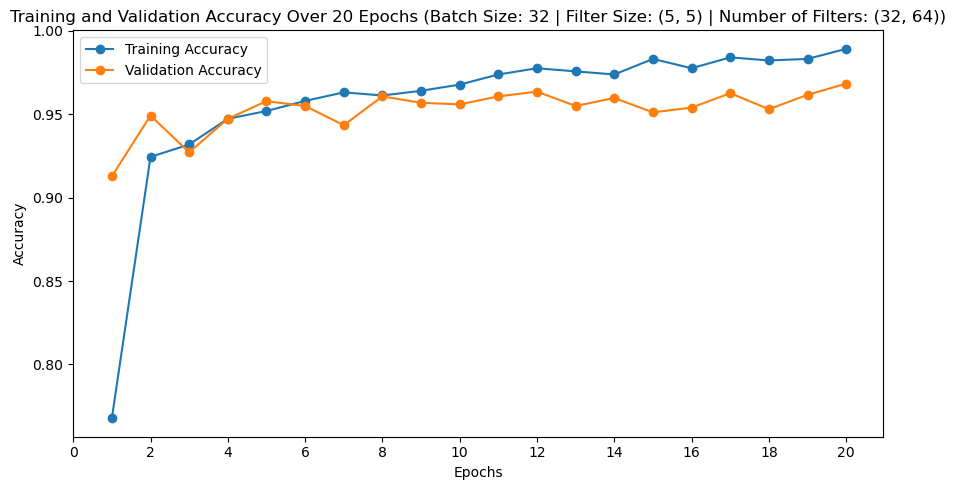

Validation Accuracy (Batch Size: 32 | Filter Size: (5, 5) | Number of Filters: (64, 128)): 0.954023003578186
Validation Loss (Batch Size: 32 | Filter Size: (5, 5) | Number of Filters: (64, 128)): 0.1705206036567688


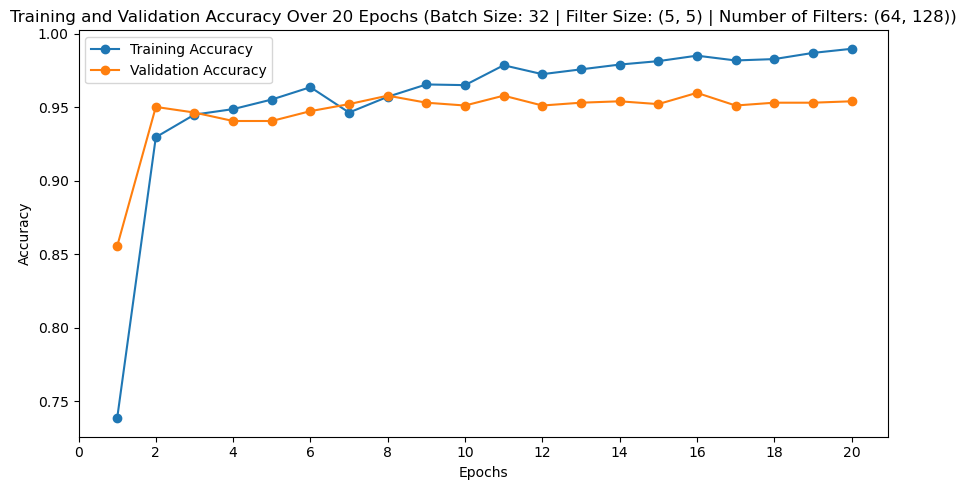

Validation Accuracy (Batch Size: 32 | Filter Size: (7, 7) | Number of Filters: (32, 64)): 0.9549808502197266
Validation Loss (Batch Size: 32 | Filter Size: (7, 7) | Number of Filters: (32, 64)): 0.15332649648189545


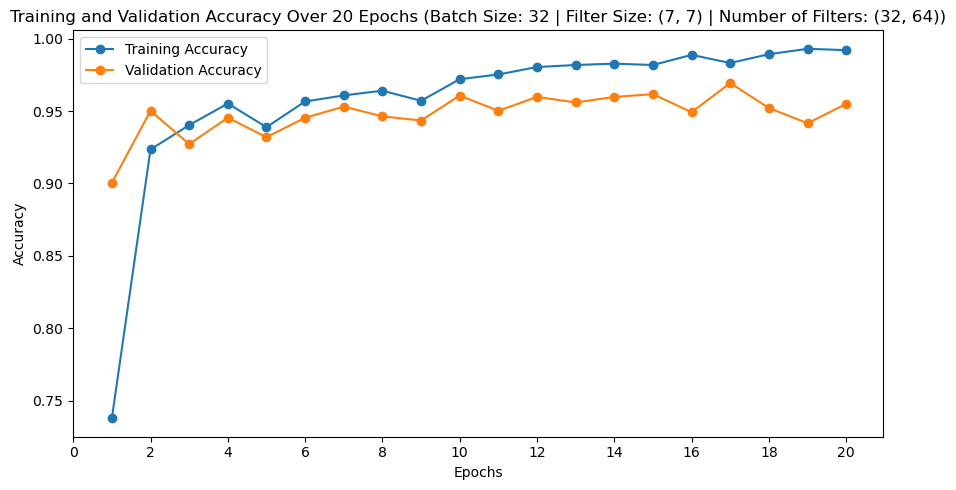

Validation Accuracy (Batch Size: 32 | Filter Size: (7, 7) | Number of Filters: (64, 128)): 0.9607279896736145
Validation Loss (Batch Size: 32 | Filter Size: (7, 7) | Number of Filters: (64, 128)): 0.13011884689331055


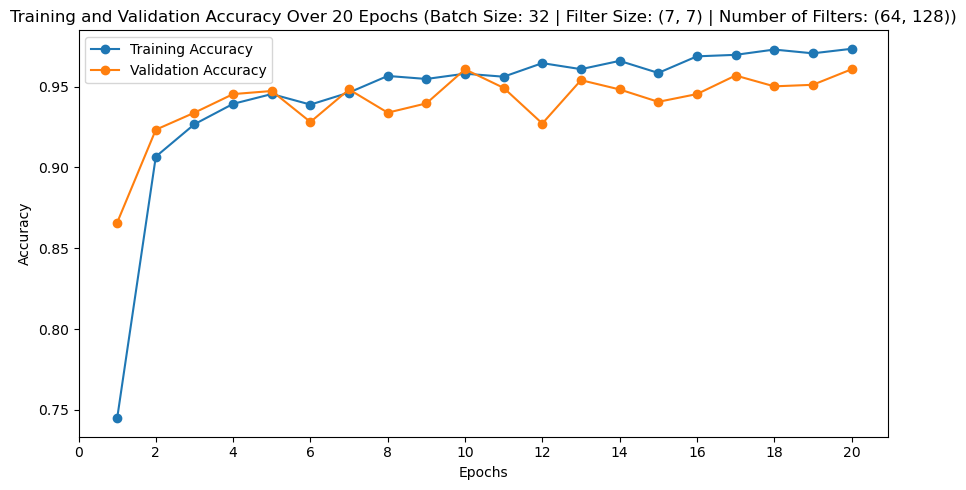

Validation Accuracy (Batch Size: 64 | Filter Size: (3, 3) | Number of Filters: (32, 64)): 0.9521072506904602
Validation Loss (Batch Size: 64 | Filter Size: (3, 3) | Number of Filters: (32, 64)): 0.21415764093399048


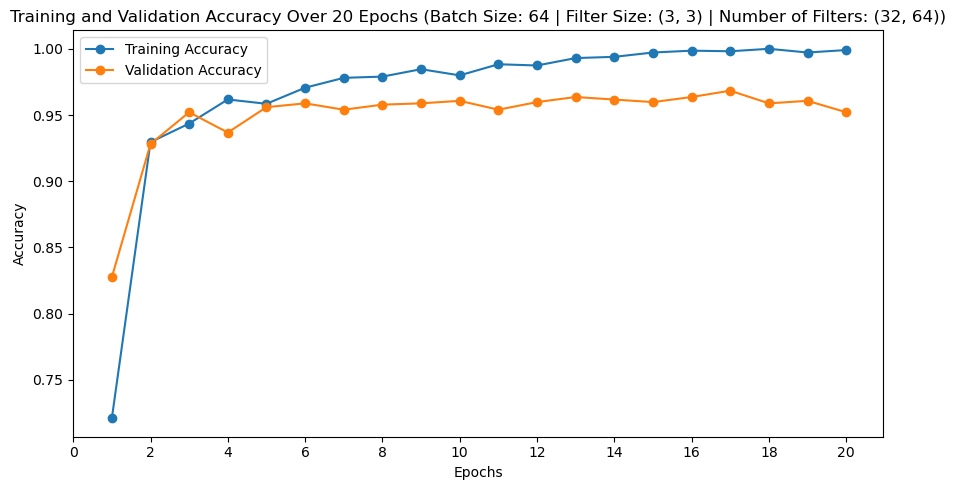

Validation Accuracy (Batch Size: 64 | Filter Size: (3, 3) | Number of Filters: (64, 128)): 0.959770143032074
Validation Loss (Batch Size: 64 | Filter Size: (3, 3) | Number of Filters: (64, 128)): 0.15676574409008026


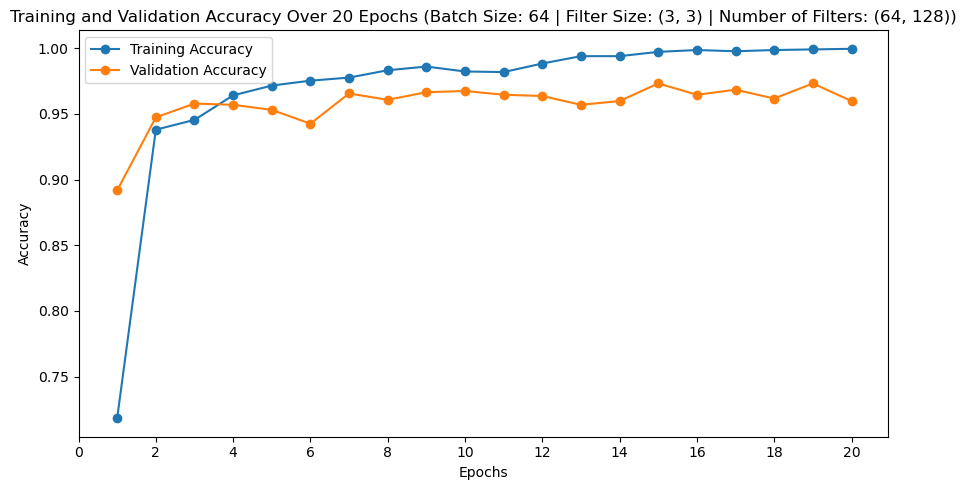

Validation Accuracy (Batch Size: 64 | Filter Size: (5, 5) | Number of Filters: (32, 64)): 0.9588122367858887
Validation Loss (Batch Size: 64 | Filter Size: (5, 5) | Number of Filters: (32, 64)): 0.158961221575737


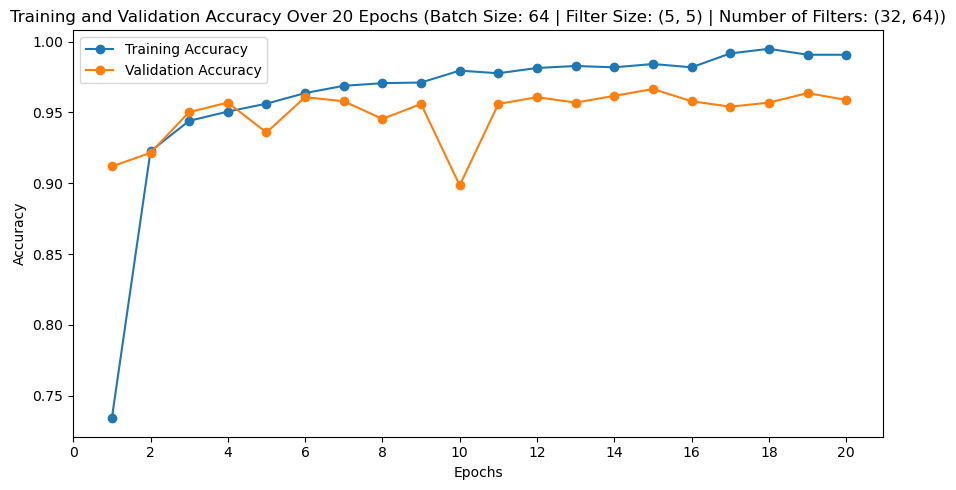

Validation Accuracy (Batch Size: 64 | Filter Size: (5, 5) | Number of Filters: (64, 128)): 0.9645593762397766
Validation Loss (Batch Size: 64 | Filter Size: (5, 5) | Number of Filters: (64, 128)): 0.13136273622512817


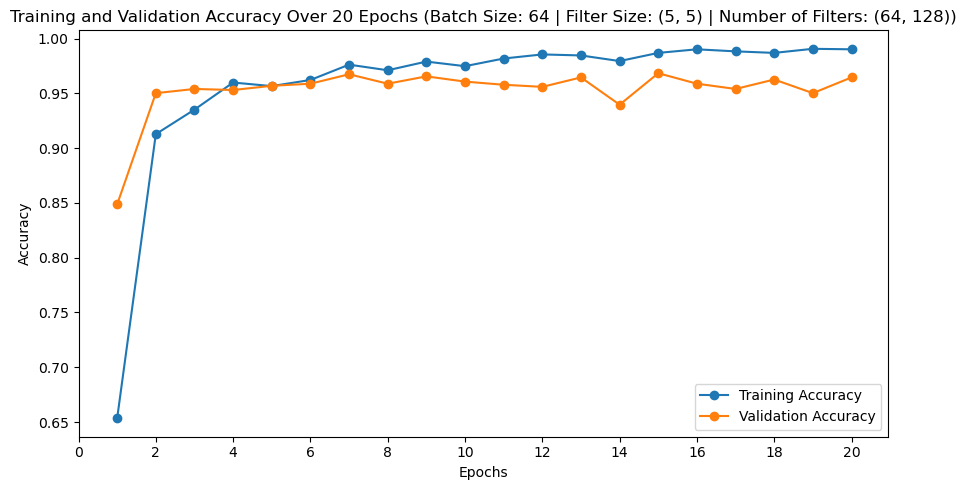

Validation Accuracy (Batch Size: 64 | Filter Size: (7, 7) | Number of Filters: (32, 64)): 0.9559386968612671
Validation Loss (Batch Size: 64 | Filter Size: (7, 7) | Number of Filters: (32, 64)): 0.1572958528995514


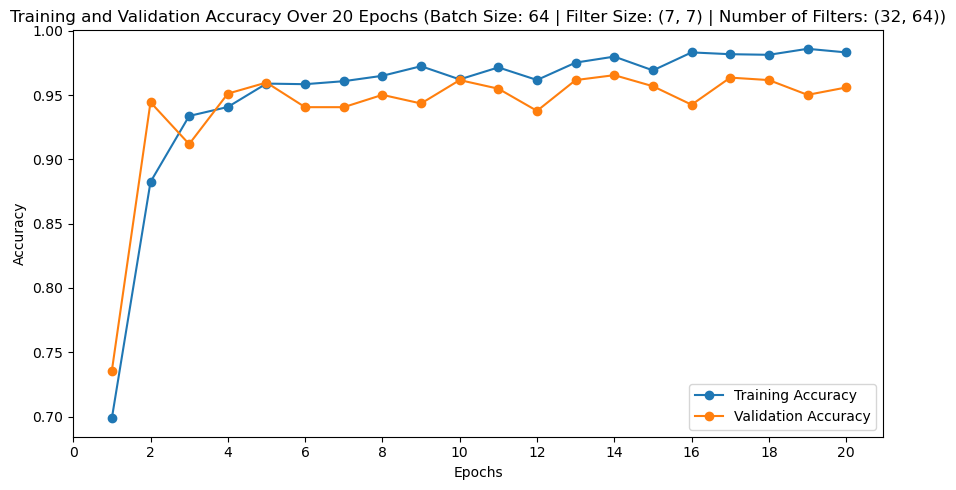

Validation Accuracy (Batch Size: 64 | Filter Size: (7, 7) | Number of Filters: (64, 128)): 0.9645593762397766
Validation Loss (Batch Size: 64 | Filter Size: (7, 7) | Number of Filters: (64, 128)): 0.09923085570335388


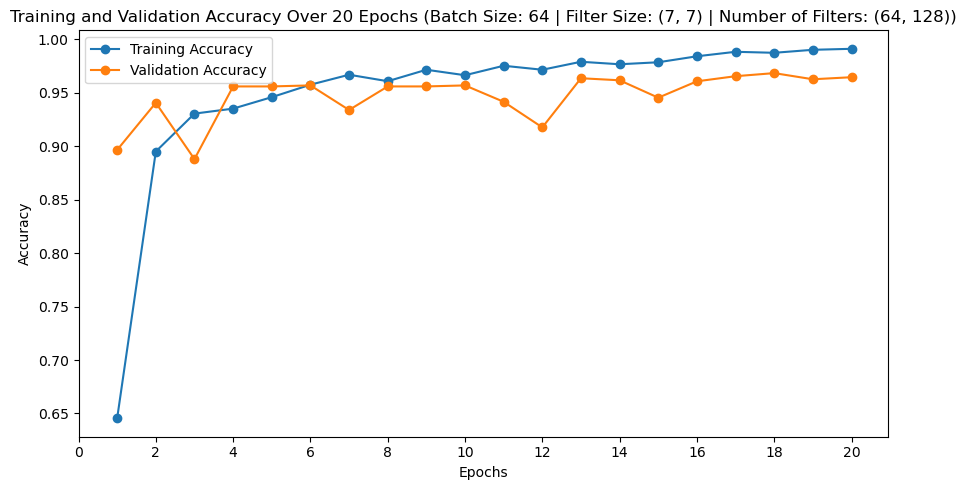

In [11]:
batch_sizes = [16, 32, 64]
filter_sizes = [(3,3), (5,5), (7,7)]
num_filters = [(32,64), (64,128)]
hyper_params = list(product(batch_sizes, filter_sizes, num_filters))
accuracy_results = []

for param_config in hyper_params:
    batch_size = param_config[0]
    filter_size = param_config[1]
    num_filter = param_config[2]
    
    config_history = evaluate_cnn(batch_size, filter_size, num_filter)
    val_accuracy = config_history.history['val_accuracy'][-1]
    val_loss = config_history.history['val_loss'][-1]

    print(f'Validation Accuracy (Batch Size: {batch_size} | Filter Size: {filter_size} | Number of Filters: {num_filter}):', val_accuracy)
    print(f'Validation Loss (Batch Size: {batch_size} | Filter Size: {filter_size} | Number of Filters: {num_filter}):', val_loss)

    plt.figure(figsize=(9, 5))
    plt.plot(range(1,21), config_history.history['accuracy'], label='Training Accuracy', marker='o')
    plt.plot(range(1,21), config_history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title(f'Training and Validation Accuracy Over 20 Epochs (Batch Size: {batch_size} | Filter Size: {filter_size} | Number of Filters: {num_filter})')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.xticks(range(0,21,2))
    plt.tight_layout()
    plt.show()

    accuracy_results.append(val_accuracy)

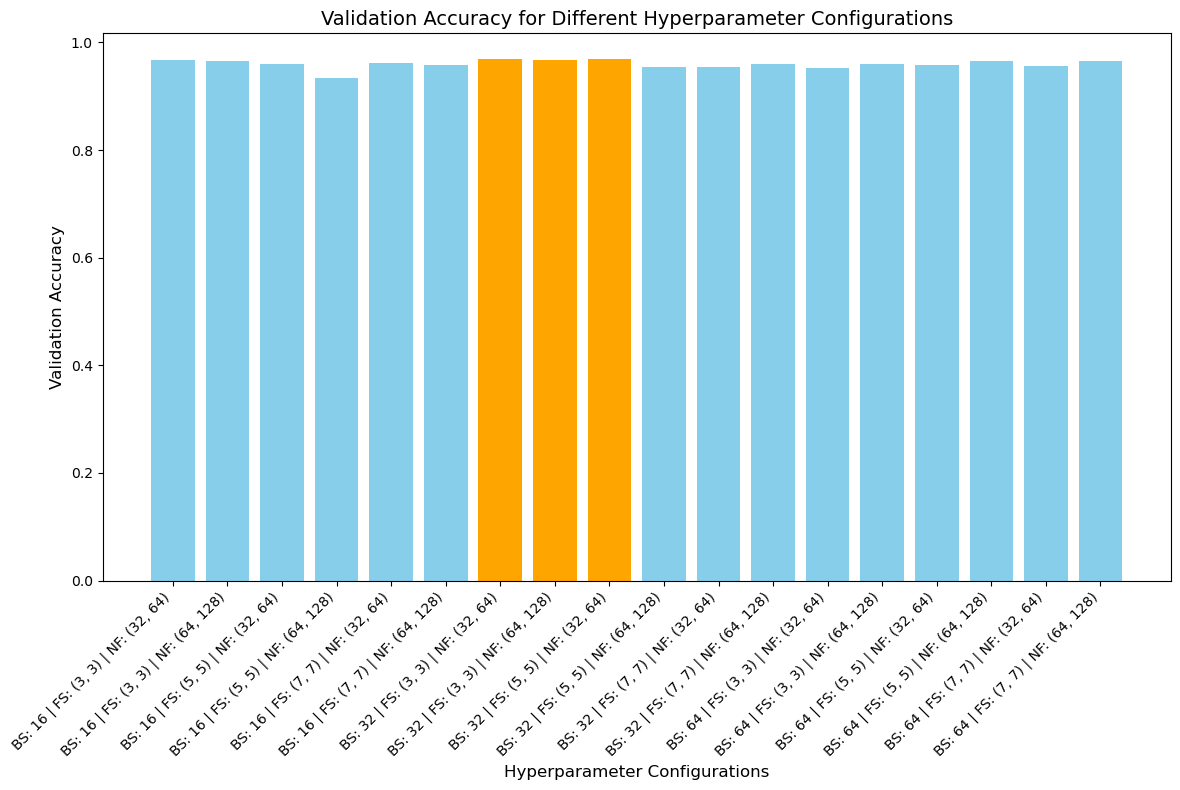

In [12]:
top_3_indices = np.argsort(accuracy_results)[-3:]
bar_colors = ['skyblue' if i not in top_3_indices else 'orange' for i in range(len(accuracy_results))]

plt.figure(figsize=(12, 8))
plt.bar([f'BS: {config[0]} | FS: {config[1]} | NF: {config[2]}' for config in hyper_params], accuracy_results, color=bar_colors)
plt.xticks(rotation=45, ha='right')
plt.title('Validation Accuracy for Different Hyperparameter Configurations', fontsize=14)
plt.xlabel('Hyperparameter Configurations', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
results = {'Batch Size': [config[0] for config in hyper_params], 
           'Filter Size': [config[1] for config in hyper_params], 
           'Number of Filters': [config[2] for config in hyper_params],
           'Validation Accuracy': accuracy_results}
results_df = pd.DataFrame(results).sort_values(by='Validation Accuracy', ascending=False)
results_df

,Batch Size,Filter Size,Number of Filters,Validation Accuracy
6,32,"(3, 3)","(32, 64)",0.968391
8,32,"(5, 5)","(32, 64)",0.968391
7,32,"(3, 3)","(64, 128)",0.967433
0,16,"(3, 3)","(32, 64)",0.966475
1,16,"(3, 3)","(64, 128)",0.965517
15,64,"(5, 5)","(64, 128)",0.964559
17,64,"(7, 7)","(64, 128)",0.964559
4,16,"(7, 7)","(32, 64)",0.961686
11,32,"(7, 7)","(64, 128)",0.960728
13,64,"(3, 3)","(64, 128)",0.959770


From the results above we can see that models 6 and 8 are the two best-performing models, whereas models 3 and 12 are the two worst-performing models. Comparing the parameter configurations of these models we can see that both of the best-performing models have a batch size of 32 and the worst-performing models use batch sizes of 16 and 64. This shows that there is usually a sweet spot for the batch size where we can have the smoothest and most efficient convergence toward a local minimum of the loss function. If the batch size is too large, the updates from the gradient descent might be too large, causing us to skip over the local minimum. On the other hand, if the batch size is too small we might not converge quickly enough toward the local minimum or get stuck at a plateau in the loss function that is not optimal. Looking at the other parameters we can see that the filter sizes actually do not vary much between the best and worst-performing models. However, we can see that models using filter sizes of 3x3 tend to perform better than models that use filter sizes of 5x5 or 7x7. This shows that for this dataset, using filters that can capture finer details in the images usually yields the best performance. If the filters are too large then we will focus on broader, more irrelevant features and if the filters are too small then we might be looking too closely for patterns that are not present in the images. Finally, analyzing the number of filters we can see that the two best-performing models both use (32,64) filters and the worst-performing model uses (64,128) filters. This shows that using more filters is not always better as we risk overfitting if we attempt to capture too many patterns in the training images. However, if we do not use enough filters we could also risk underfitting by not capturing enough rich patterns to generalize on the validation images. In general, it seems that finding the best hyperparameters is a balancing act where we want to smoothly and efficiently find an optimal minimum in the loss function while also reducing the risk of underfitting or overfitting the training data. When looking at the performance plots we can see that the best-performing models are usually the ones that have smoother behavior in the validation performance as we continue to train on each epoch. 